In [1]:
%matplotlib widget
import graph as g

In [2]:
import numpy as np
import random

In [3]:
import lib

In [4]:
import load_mnist as mnist

# Network defination

In [108]:
class Network(object):
    def __init__(self, sizes):
        self.sizes = sizes
        self.weights = [np.random.randn(x,y) * 1.2 for x,y in zip(sizes[1:], sizes[:-1])]
        self.biases = [np.random.randn(x,1) * 1.2 for x in sizes[1:]]

    def feedforward(self, a):
        for (w, b) in zip(self.weights, self.biases):
            a = lib.sigmoid(w @ a + b)

        return a

    def evaluate(self, validation_set, lmd, n):
        ay = [(self.feedforward(x), y) for x,y in validation_set]
        
        loss = lib.cross_entropy_error(ay)
        percent = lib.accuracy_percent(ay)
        
        return loss, percent

    def SGD(self, training_set, epochs, mini_batch_size, eta, lmd, validation_set = None, tl=None, tp=None, vl=None, vp=None):
        n = len(training_set)
        graph_epochs = []
        
        val_loss = []
        val_percent = []
        train_loss = []
        train_percent = []

        for epoch in range(epochs):
            np.random.shuffle(training_set)
            
            mini_batches = [training_set[k: k+mini_batch_size] for k in range(0, n, mini_batch_size)]
            loss, percent = self.mini_batch_update(mini_batches, eta, lmd, n)
            
            graph_epochs.append(epoch+1)
            train_loss.append(loss)
            train_percent.append(percent)

            if tl:
                g.pltsin(tl, graph_epochs, train_loss)
            if tp:
                g.pltsin(tp, graph_epochs, train_percent)

            if validation_set != None:
                loss, percent = self.evaluate(validation_set, lmd, n)

                val_loss.append(loss)
                val_percent.append(percent)
                
                if vl:
                    g.pltsin(vl, graph_epochs, val_loss)
                if vp:
                    g.pltsin(vp, graph_epochs, val_percent)
                
                print("Epoch {0} completed. Loss: {1}".format(epoch+1, loss))
            else:
                print("Epoch {0} completed.".format(epoch+1))

    def mini_batch_update(self, mini_batches, eta, lmd, n):
        agg_loss = []
        agg_percent = []
        
        for mini_batch in mini_batches:
            nabla_w = [np.zeros(w.shape) for w in self.weights]
            nabla_b = [np.zeros(b.shape) for b in self.biases]

            ay = []
            
            for x, y in mini_batch:
                a = x
                ass = [a]
                zss = []
                delta_nabla_w = [np.zeros(w.shape) for w in self.weights]
                delta_nabla_b = [np.zeros(b.shape) for b in self.biases]

                for w,b in zip(self.weights, self.biases):
                    z = w @ a + b
                    zss.append(z)

                    a = lib.sigmoid(z)
                    ass.append(a)

                # backprop
                error = None
                for l in range(-1, -len(self.sizes), -1):
                    if l == -1:
                        error = lib.cross_entropy_error_prime(a, y)
                    else:
                        error = (self.weights[l+1].transpose() @ error) * lib.sigmoid_prime(zss[l])

                    delta_nabla_w[l] = error @ ass[l-1].transpose()
                    delta_nabla_b[l] = error

                nabla_w = [nw + dnw for nw, dnw in zip(nabla_w, delta_nabla_w)]
                nabla_b = [nb + dnb for nb, dnb in zip(nabla_b, delta_nabla_b)]

                ay.append((a,y))

            # average out nablas, multiply them by learning rate and adjust weights and biases
            m = len(mini_batch)

            w_decay = 1 - eta*lmd/n
            self.weights = [w_decay * w + nw * -eta/m for w, nw in zip(self.weights, nabla_w)]
            self.biases = [b + nb * -eta/m for b, nb in zip(self.biases, nabla_b)]    

            loss = lib.cross_entropy_error(ay) 
            percent = lib.accuracy_percent(ay)

            agg_loss.append(loss)
            agg_percent.append(percent)

        return sum(agg_loss) / len(mini_batches), sum(agg_percent) / len(mini_batches)

    def calc_reg_cost_param(self, lmd, n):
         return (lmd/2*n)*sum([np.linalg.norm(w) for w in self.weights])

# Run

In [91]:
epochs = 30

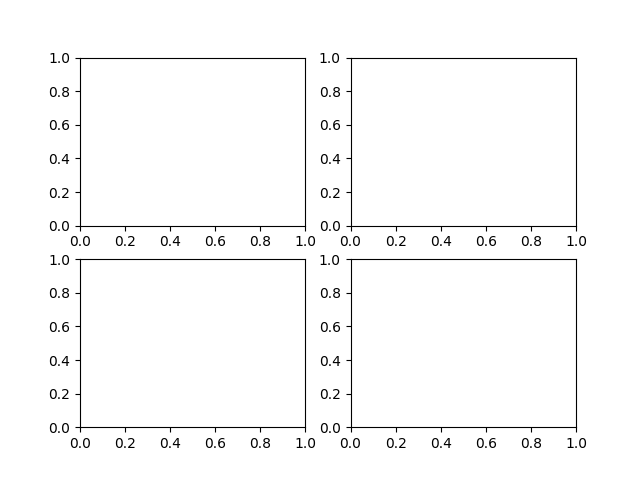

In [96]:
g.plt.close()

ax, fig = g.createplot(s=(2,2))
tl, tp = ax[0][0], ax[0][1]
vl, vp = ax[1][0], ax[1][1]

label = ['Train', 'Validate']

for gl, l in zip([tl,vl], label):
    gl.set_ylabel("Loss ({0})".format(l))
    gl.set_xlim(0,epochs)
    gl.set_ylim(0,5)

for gp, l in zip([tp,vp], label):
    gp.set_ylabel("Accuracy ({0})".format(l))
    gp.set_xlim(0,epochs)
    gp.set_ylim(50,100)


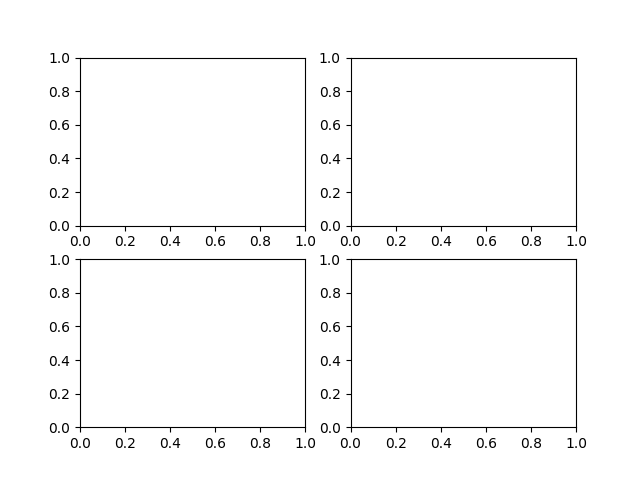

In [111]:
g.plt.close()

ax, fig = g.createplot(s=(2,2))
tl, tp = ax[0][0], ax[0][1]
vl, vp = ax[1][0], ax[1][1]

label = ['Train', 'Validate']

for gl, l in zip([tl,vl], label):
    gl.set_ylabel("Loss ({0})".format(l))
    gl.set_xlim(0,epochs)
    gl.set_ylim(0,10)

for gp, l in zip([tp,vp], label):
    gp.set_ylabel("Accuracy ({0})".format(l))
    gp.set_xlim(0,epochs)
    gp.set_ylim(0,50)


In [115]:
net = Network([784, 30, 10])
net.SGD(mnist.training_set[0:1000], epochs, 10, .08, 0.1, validation_set = mnist.validation_set, tp=(tp,fig), tl=(tl,fig), vp=(vp,fig), vl=(vl,fig))

Epoch 1 completed. Loss: 4.099940350136652
Epoch 2 completed. Loss: 3.545304412676842
Epoch 3 completed. Loss: 3.3178247899122613
Epoch 4 completed. Loss: 3.106244241528505
Epoch 5 completed. Loss: 2.9107076078585923
Epoch 6 completed. Loss: 2.920829640597616
Epoch 7 completed. Loss: 2.819863224808845
Epoch 8 completed. Loss: 2.755722763200881
Epoch 9 completed. Loss: 2.678261745502144
Epoch 10 completed. Loss: 2.63832138159448
Epoch 11 completed. Loss: 2.5854705577741752
Epoch 12 completed. Loss: 2.5619971837339803
Epoch 13 completed. Loss: 2.5367897929090093
Epoch 14 completed. Loss: 2.5395102384345973
Epoch 15 completed. Loss: 2.541667805305104
Epoch 16 completed. Loss: 2.508941662536944
Epoch 17 completed. Loss: 2.506506235065717
Epoch 18 completed. Loss: 2.4834463865612637
Epoch 19 completed. Loss: 2.508013256944084
Epoch 20 completed. Loss: 2.4625730419492804
Epoch 21 completed. Loss: 2.5355820593394953
Epoch 22 completed. Loss: 2.4926726161909056
Epoch 23 completed. Loss: 2.4398